# Stock Portfolio Performance & Risk Analysis

In this project, I analyzed a portfolio of 10 Indian stocks using Python. I looked at how the portfolio performed over time, compared individual stocks, and studied basic risk and return measures using historical stock price data from 2020 to 2025.

In [12]:
!pip install yfinance

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [14]:
portfolio = [
    "DIXON.NS",
    "PTC.NS",
    "LT.NS",
    "BEL.NS",
    "SBIN.NS",
    "TRENT.NS",
    "INFY.NS",
    "ADANIENT.NS",
    "IOC.NS",
    "CUMMINSIND.NS"
]

In [15]:
data = yf.download(
    portfolio,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)

[*********************100%***********************]  10 of 10 completed


In [16]:
prices = data["Close"]

prices.head()

Ticker,ADANIENT.NS,BEL.NS,CUMMINSIND.NS,DIXON.NS,INFY.NS,IOC.NS,LT.NS,PTC.NS,SBIN.NS,TRENT.NS
Date,,,,,,,,,,
2020-01-01,205.794495,29.713726,490.826538,754.723450,619.740295,53.147774,1180.674561,36.422234,303.138519,526.402710
2020-01-02,209.111374,30.603806,505.849640,778.472107,617.931946,53.590855,1212.536255,36.486584,307.534393,538.031006
2020-01-03,206.240036,29.951077,509.360931,787.760254,627.436035,53.527554,1203.297607,36.937038,302.458679,532.614319
2020-01-06,197.576569,28.764303,507.316345,789.145508,621.422485,52.704697,1186.803589,35.746555,289.134918,526.700928
2020-01-07,202.032104,28.586290,509.849792,844.117126,612.212708,52.557003,1190.183472,35.810909,288.591095,529.682495


In [17]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1487 entries, 2020-01-01 to 2025-12-31
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ADANIENT.NS    1487 non-null   float64
 1   BEL.NS         1487 non-null   float64
 2   CUMMINSIND.NS  1487 non-null   float64
 3   DIXON.NS       1487 non-null   float64
 4   INFY.NS        1487 non-null   float64
 5   IOC.NS         1487 non-null   float64
 6   LT.NS          1487 non-null   float64
 7   PTC.NS         1487 non-null   float64
 8   SBIN.NS        1487 non-null   float64
 9   TRENT.NS       1487 non-null   float64
dtypes: float64(10)
memory usage: 127.8 KB


In [18]:
prices.isnull().sum()

,0
Ticker,
ADANIENT.NS,0
BEL.NS,0
CUMMINSIND.NS,0
DIXON.NS,0
INFY.NS,0
IOC.NS,0
LT.NS,0
PTC.NS,0
SBIN.NS,0


In [19]:
prices.shape

(1487, 10)

In [20]:
prices.columns

Index(['ADANIENT.NS', 'BEL.NS', 'CUMMINSIND.NS', 'DIXON.NS', 'INFY.NS',
       'IOC.NS', 'LT.NS', 'PTC.NS', 'SBIN.NS', 'TRENT.NS'],
      dtype='object', name='Ticker')

In [21]:
prices.describe().round(2)

Ticker,ADANIENT.NS,BEL.NS,CUMMINSIND.NS,DIXON.NS,INFY.NS,IOC.NS,LT.NS,PTC.NS,SBIN.NS,TRENT.NS
count,1487.00,1487.00,1487.00,1487.00,1487.00,1487.00,1487.00,1487.00,1487.00,1487.00
mean,1986.72,149.06,1761.00,6751.41,1315.76,85.78,2286.79,102.17,526.80,2523.61
std,1042.04,122.93,1220.52,5178.18,317.25,42.77,1021.09,54.91,216.41,2127.48
min,120.55,17.63,258.45,635.43,442.78,31.68,646.97,21.11,136.73,400.93
25%,1412.89,53.58,803.84,3465.40,1181.49,52.98,1430.88,61.43,386.94,877.90
50%,2245.38,97.85,1358.92,4425.76,1365.65,65.66,2036.13,79.79,518.39,1377.48
75%,2616.83,268.72,2859.08,11503.02,1513.59,130.68,3419.69,160.43,737.65,4505.02
max,4157.74,429.42,4541.71,18931.72,1901.08,173.21,4052.72,217.49,966.48,8218.05


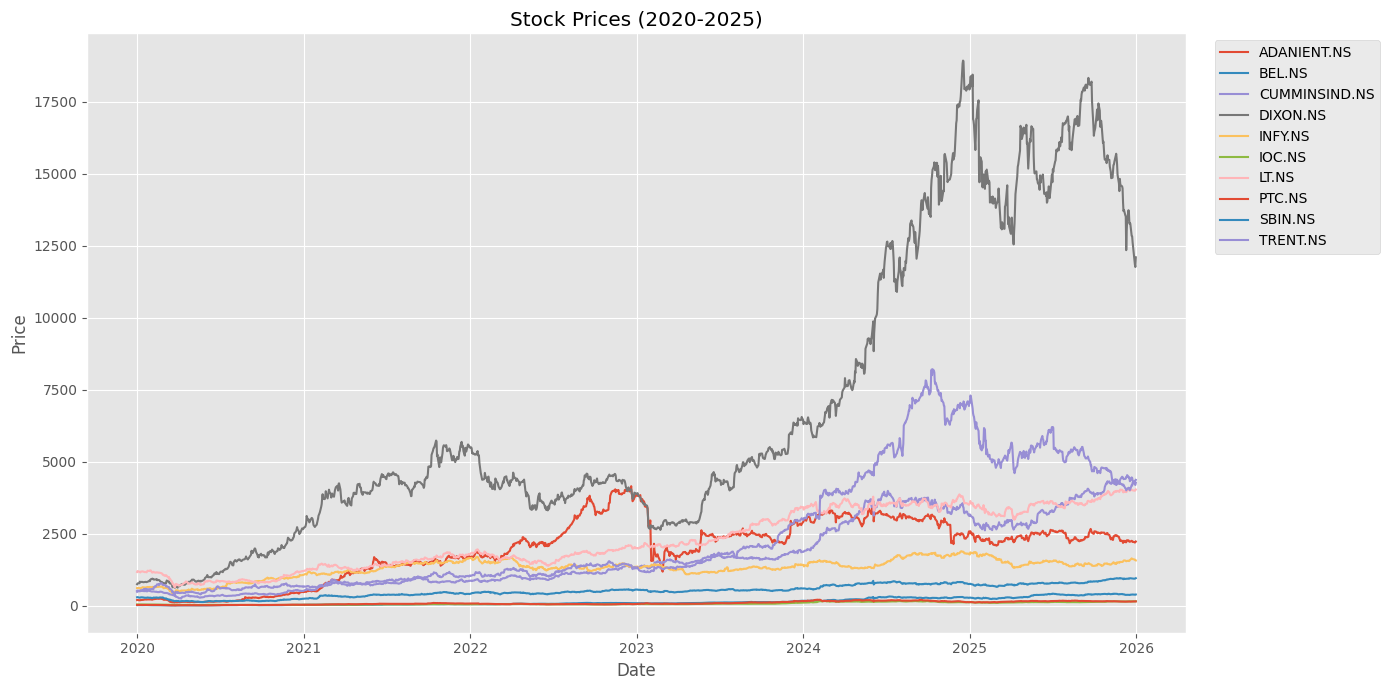

In [99]:
plt.figure(figsize=(14,7))

for company in prices.columns:
    plt.plot(prices[company], label=company)

plt.title("Stock Prices (2020-2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout()

plt.savefig("images/stock_prices.png", dpi=300, bbox_inches="tight")

plt.show()

The stocks have very different price ranges, so comparing them directly is not meaningful. In the next step, I'll normalize the prices so that they all start from the same value.

In [23]:
normalized_prices = prices / prices.iloc[0] * 100

normalized_prices.head()

Ticker,ADANIENT.NS,BEL.NS,CUMMINSIND.NS,DIXON.NS,INFY.NS,IOC.NS,LT.NS,PTC.NS,SBIN.NS,TRENT.NS
Date,,,,,,,,,,
2020-01-01,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2020-01-02,101.611743,102.995516,103.060776,103.146670,99.708208,100.833677,102.698601,100.176678,101.450121,102.209011
2020-01-03,100.216498,100.798791,103.776160,104.377339,101.241768,100.714573,101.916112,101.413436,99.775733,101.180011
2020-01-06,96.006732,96.804767,103.359600,104.560884,100.271435,99.166330,100.519112,98.144874,95.380461,100.056652
2020-01-07,98.171773,96.205674,103.875759,111.844561,98.785364,98.888438,100.805380,98.321563,95.201064,100.623056


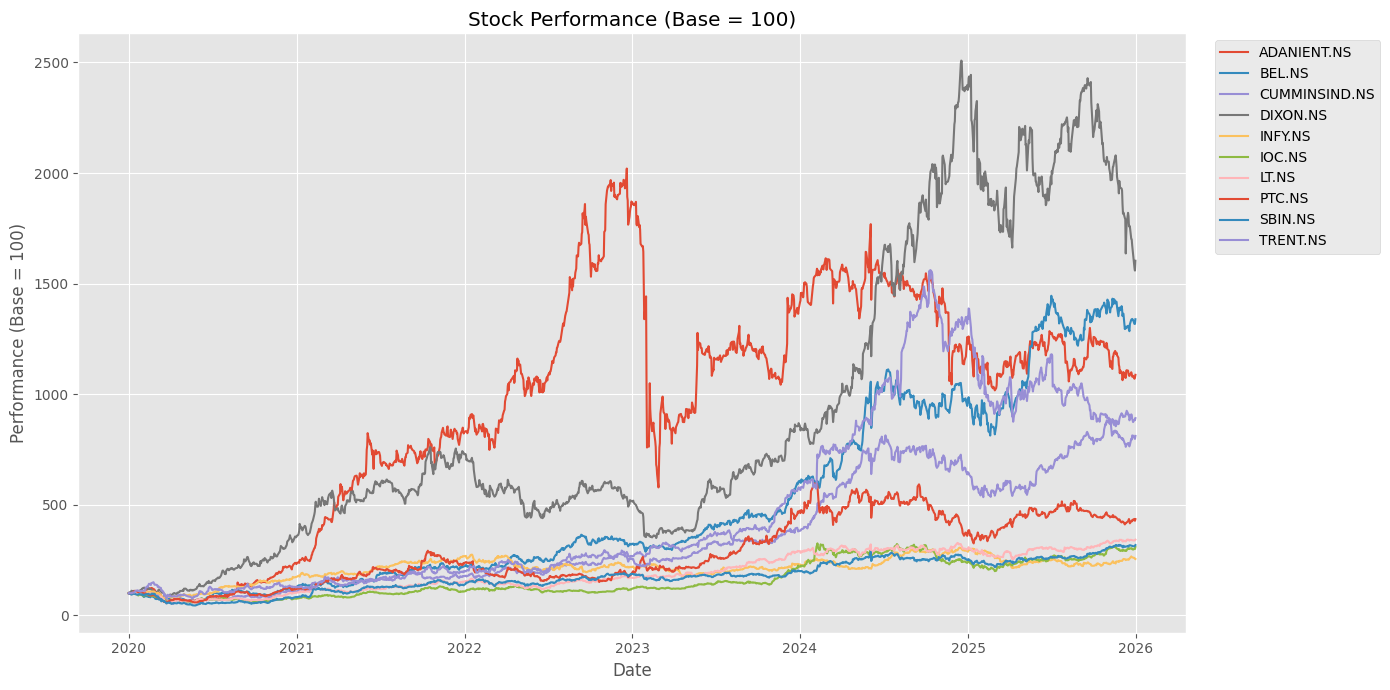

In [103]:
plt.figure(figsize=(14,7))

for company in normalized_prices.columns:
    plt.plot(normalized_prices[company], label=company)

plt.title("Stock Performance (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Performance (Base = 100)")

plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout()

plt.savefig("images/normalized_prices.png", dpi=300, bbox_inches="tight")

plt.show()

All stocks start from the same value (100), making it easier to compare their performance over time. Dixon Technologies and Adani Enterprises showed the highest growth, while Infosys, IOC and L&T had relatively steady performance. COVID recovery is clearly visible.

In [27]:
daily_returns = prices.pct_change()

daily_returns.head()

Ticker,ADANIENT.NS,BEL.NS,CUMMINSIND.NS,DIXON.NS,INFY.NS,IOC.NS,LT.NS,PTC.NS,SBIN.NS,TRENT.NS
Date,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,0.016117,0.029955,0.030608,0.031467,-0.002918,0.008337,0.026986,0.001767,0.014501,0.022090
2020-01-03,-0.013731,-0.021328,0.006941,0.011931,0.015380,-0.001181,-0.007619,0.012346,-0.016505,-0.010068
2020-01-06,-0.042007,-0.039624,-0.004014,0.001758,-0.009584,-0.015373,-0.013707,-0.032230,-0.044052,-0.011103
2020-01-07,0.022551,-0.006189,0.004994,0.069660,-0.014820,-0.002802,0.002848,0.001800,-0.001881,0.005661


Instead of looking at stock prices, I calculated daily percentage returns. Returns are more useful for comparing stocks and measuring risk.

In [28]:
daily_returns = prices.pct_change().dropna()

daily_returns.head()

Ticker,ADANIENT.NS,BEL.NS,CUMMINSIND.NS,DIXON.NS,INFY.NS,IOC.NS,LT.NS,PTC.NS,SBIN.NS,TRENT.NS
Date,,,,,,,,,,
2020-01-02,0.016117,0.029955,0.030608,0.031467,-0.002918,0.008337,0.026986,0.001767,0.014501,0.022090
2020-01-03,-0.013731,-0.021328,0.006941,0.011931,0.015380,-0.001181,-0.007619,0.012346,-0.016505,-0.010068
2020-01-06,-0.042007,-0.039624,-0.004014,0.001758,-0.009584,-0.015373,-0.013707,-0.032230,-0.044052,-0.011103
2020-01-07,0.022551,-0.006189,0.004994,0.069660,-0.014820,-0.002802,0.002848,0.001800,-0.001881,0.005661
2020-01-08,-0.012497,-0.009341,0.008456,-0.021842,-0.013326,-0.021678,-0.021923,-0.007188,0.004397,-0.001876


The first row will always be NaN because there's no previous day to compare against so I dropped it.

In [32]:
portfolio_returns = daily_returns.mean(axis=1)
portfolio_growth = (1 + portfolio_returns).cumprod()

portfolio_returns.head()

,0
Date,
2020-01-02,0.017891
2020-01-03,-0.002383
2020-01-06,-0.020993
2020-01-07,0.008182
2020-01-08,-0.009682


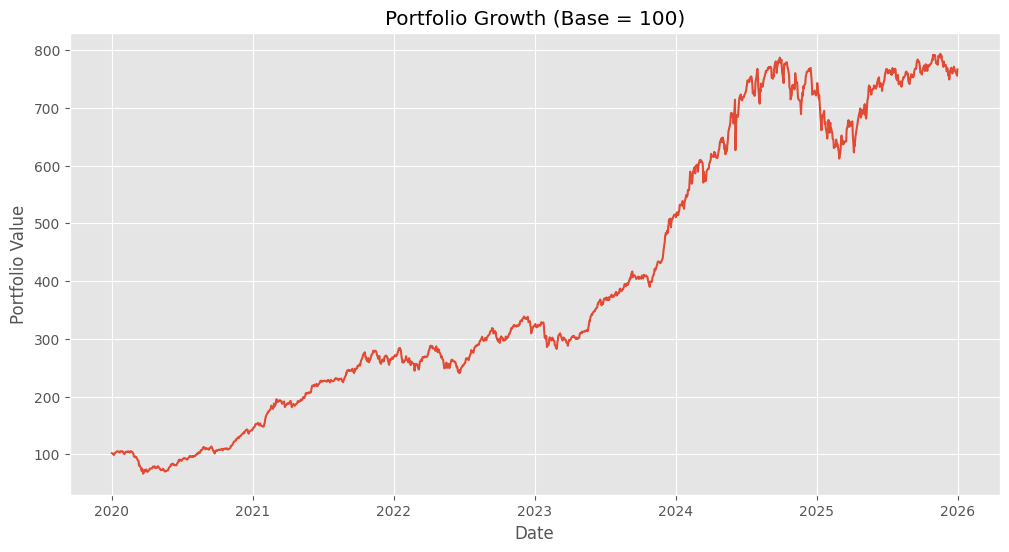

In [104]:
plt.figure(figsize=(12,6))
plt.plot(portfolio_growth * 100)

plt.title("Portfolio Growth (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.savefig("portfolio_growth.png", dpi=300, bbox_inches="tight")

plt.show()

Portfolio recovered after COVID.
Strong growth during 2021 and 2024.
Corrections in 2022 and 2025 are visible.
Overall trend is upward.

In [40]:
annual_return = daily_returns.mean() * 252
annual_volatility = daily_returns.std() * np.sqrt(252)

summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

summary.round(3)

,Annual Return,Annual Volatility
Ticker,,
ADANIENT.NS,0.538,0.510
BEL.NS,0.510,0.371
CUMMINSIND.NS,0.423,0.322
DIXON.NS,0.554,0.406
INFY.NS,0.196,0.274
IOC.NS,0.233,0.287
LT.NS,0.247,0.276
PTC.NS,0.329,0.399
SBIN.NS,0.245,0.310


I calculated the annual return and annual volatility for each stock to compare their performance and risk over the six-year period.

In [41]:
summary.sort_values("Annual Return", ascending=False).round(3)

,Annual Return,Annual Volatility
Ticker,,
DIXON.NS,0.554,0.406
ADANIENT.NS,0.538,0.510
BEL.NS,0.510,0.371
TRENT.NS,0.430,0.386
CUMMINSIND.NS,0.423,0.322
PTC.NS,0.329,0.399
LT.NS,0.247,0.276
SBIN.NS,0.245,0.310
IOC.NS,0.233,0.287


In [42]:
summary.sort_values("Annual Volatility", ascending=False).round(3)

,Annual Return,Annual Volatility
Ticker,,
ADANIENT.NS,0.538,0.510
DIXON.NS,0.554,0.406
PTC.NS,0.329,0.399
TRENT.NS,0.430,0.386
BEL.NS,0.510,0.371
CUMMINSIND.NS,0.423,0.322
SBIN.NS,0.245,0.310
IOC.NS,0.233,0.287
LT.NS,0.247,0.276


In [45]:
#in %
summary["Annual Return"] *= 100
summary["Annual Volatility"] *= 100

In [46]:
summary.sort_values("Annual Volatility", ascending=False).round(3)

,Annual Return,Annual Volatility
Ticker,,
ADANIENT.NS,53.768,51.019
DIXON.NS,55.352,40.589
PTC.NS,32.911,39.910
TRENT.NS,42.974,38.600
BEL.NS,50.955,37.050
CUMMINSIND.NS,42.318,32.236
SBIN.NS,24.484,31.045
IOC.NS,23.274,28.676
LT.NS,24.733,27.633


Dixon had the highest annual return, while Adani showed the highest volatility. Infosys and L&T were among the more stable stocks in the portfolio.

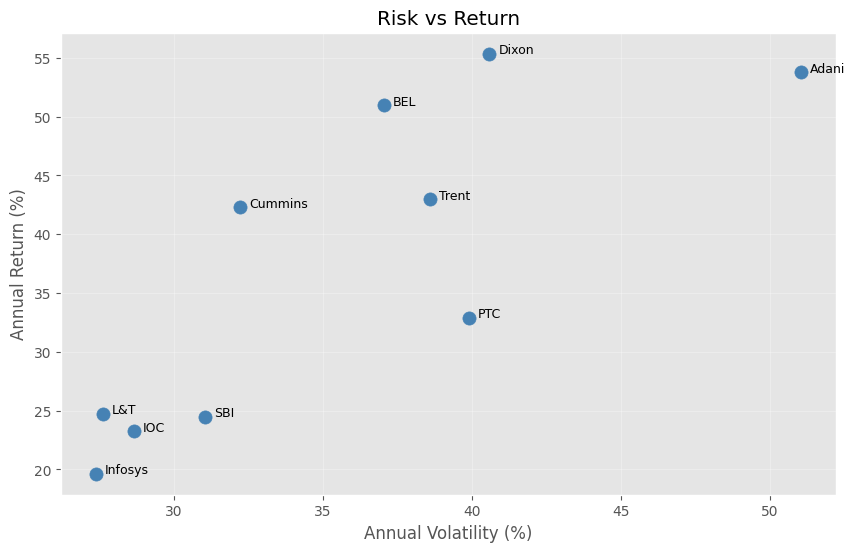

In [105]:
plt.figure(figsize=(10,6))

plt.scatter(
    summary["Annual Volatility"],
    summary["Annual Return"],
    s=90,
    color="steelblue"
)

company_names = {
    "ADANIENT.NS": "Adani",
    "BEL.NS": "BEL",
    "CUMMINSIND.NS": "Cummins",
    "DIXON.NS": "Dixon",
    "INFY.NS": "Infosys",
    "IOC.NS": "IOC",
    "LT.NS": "L&T",
    "PTC.NS": "PTC",
    "SBIN.NS": "SBI",
    "TRENT.NS": "Trent"
}
for company in summary.index:
    plt.text(
        summary.loc[company, "Annual Volatility"] + 0.3,
        summary.loc[company, "Annual Return"],
        company_names[company],
        fontsize=9
    )

plt.title("Risk vs Return")
plt.xlabel("Annual Volatility (%)")
plt.ylabel("Annual Return (%)")

plt.grid(alpha=0.3)

plt.savefig("risk_vs_return.png", dpi=300, bbox_inches="tight")

plt.show()

This chart compares risk and return for each stock. Stocks in the upper-left area offer better returns for lower risk, while stocks in the lower-right area indicate higher risk with relatively lower returns.

Correlation

In [62]:
!pip install seaborn

In [63]:
import seaborn as sns

In [64]:
correlation = daily_returns.corr()

correlation.round(2)

Ticker,ADANIENT.NS,BEL.NS,CUMMINSIND.NS,DIXON.NS,INFY.NS,IOC.NS,LT.NS,PTC.NS,SBIN.NS,TRENT.NS
Ticker,,,,,,,,,,
ADANIENT.NS,1.00,0.33,0.27,0.29,0.23,0.37,0.33,0.31,0.42,0.29
BEL.NS,0.33,1.00,0.38,0.33,0.20,0.43,0.47,0.36,0.47,0.30
CUMMINSIND.NS,0.27,0.38,1.00,0.26,0.20,0.34,0.38,0.28,0.33,0.27
DIXON.NS,0.29,0.33,0.26,1.00,0.21,0.28,0.34,0.27,0.33,0.32
INFY.NS,0.23,0.20,0.20,0.21,1.00,0.23,0.35,0.18,0.28,0.24
IOC.NS,0.37,0.43,0.34,0.28,0.23,1.00,0.44,0.40,0.50,0.27
LT.NS,0.33,0.47,0.38,0.34,0.35,0.44,1.00,0.31,0.53,0.37
PTC.NS,0.31,0.36,0.28,0.27,0.18,0.40,0.31,1.00,0.33,0.22
SBIN.NS,0.42,0.47,0.33,0.33,0.28,0.50,0.53,0.33,1.00,0.34


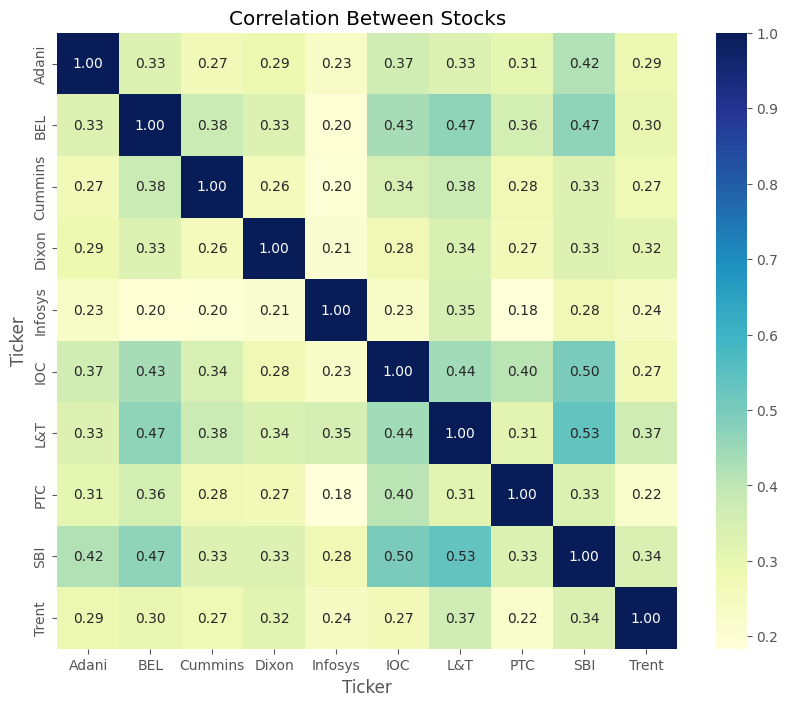

In [106]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Correlation Between Stocks")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Most of the stocks have low to moderate positive correlation, which suggests that the portfolio is reasonably diversified. No two stocks move exactly the same way, helping reduce overall portfolio risk.

In [71]:
weights = pd.Series(
    [10] * len(portfolio),
    index=company_names.values()
)

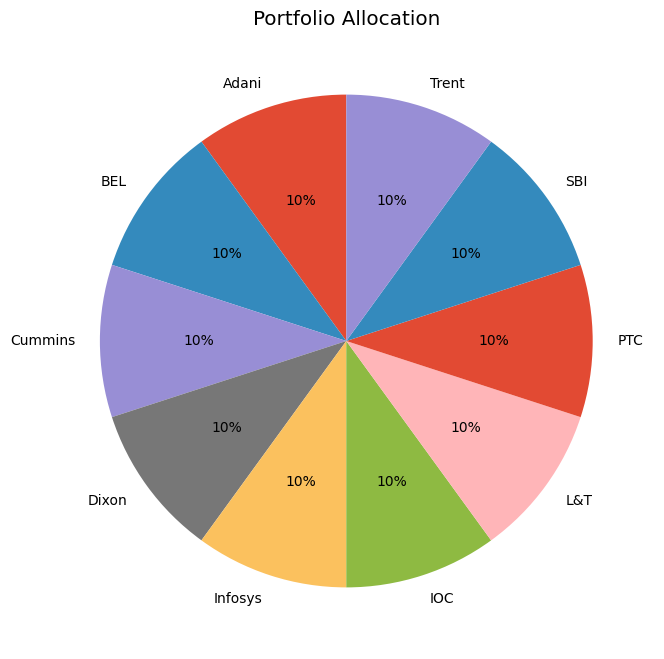

In [107]:
plt.figure(figsize=(8,8))

plt.pie(
    weights,
    labels=weights.index,
    autopct="%1.0f%%",
    startangle=90
)

plt.title("Portfolio Allocation")

plt.savefig("portfolio_allocation.png", dpi=300, bbox_inches="tight")

plt.show()

**Portfolio Risk & Sharpe Ratio**

In [73]:
risk_free = 0.06

annual_return = portfolio_returns.mean() * 252
annual_risk = portfolio_returns.std() * np.sqrt(252)

sharpe = (annual_return - risk_free) / annual_risk

In [74]:
print(f"Annual Return: {annual_return*100:.2f}%")
print(f"Annual Risk: {annual_risk*100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")

Annual Return: 37.04%
Annual Risk: 22.13%
Sharpe Ratio: 1.40


The Sharpe Ratio measures how much return the portfolio generated for each unit of risk. A higher Sharpe Ratio generally indicates better risk-adjusted performance.

In [75]:
returns = ((prices.iloc[-1] / prices.iloc[0]) - 1) * 100
returns = returns.sort_values(ascending=False)

returns.round(2)

,0
Ticker,
DIXON.NS,1503.50
BEL.NS,1239.13
ADANIENT.NS,987.83
CUMMINSIND.NS,791.97
TRENT.NS,711.68
PTC.NS,335.30
LT.NS,242.52
SBIN.NS,218.27
IOC.NS,209.30


In [76]:
print("Best Performer:", company_names[returns.idxmax()])
print("Worst Performer:", company_names[returns.idxmin()])

Best Performer: Dixon
Worst Performer: Infosys


In [78]:
returns.index = returns.index.map(company_names)

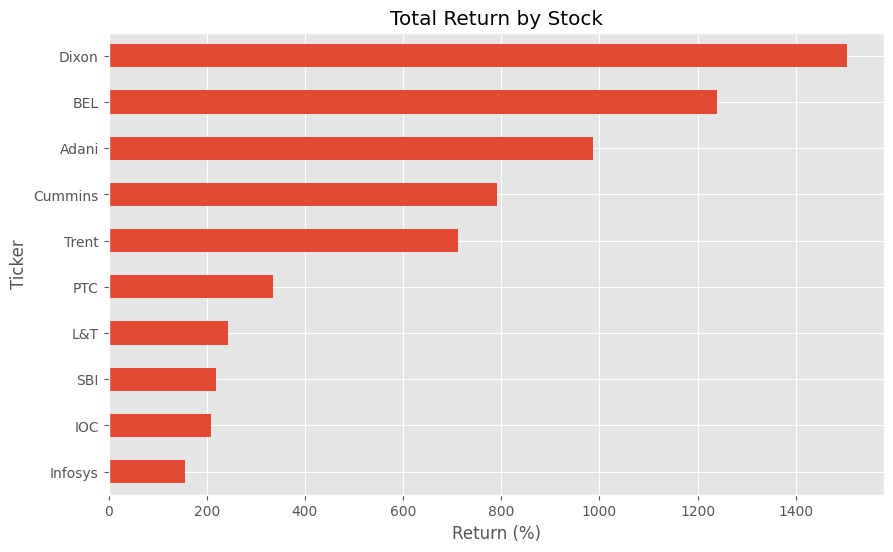

In [79]:
plt.figure(figsize=(10,6))

returns.sort_values().plot(kind="barh")

plt.title("Total Return by Stock")
plt.xlabel("Return (%)")

plt.savefig("portfolio_growth.png", dpi=300, bbox_inches="tight")

plt.show()

Dixon Technologies delivered the highest return during the analysis period, while the lower-performing stocks showed more stable but comparatively modest growth.

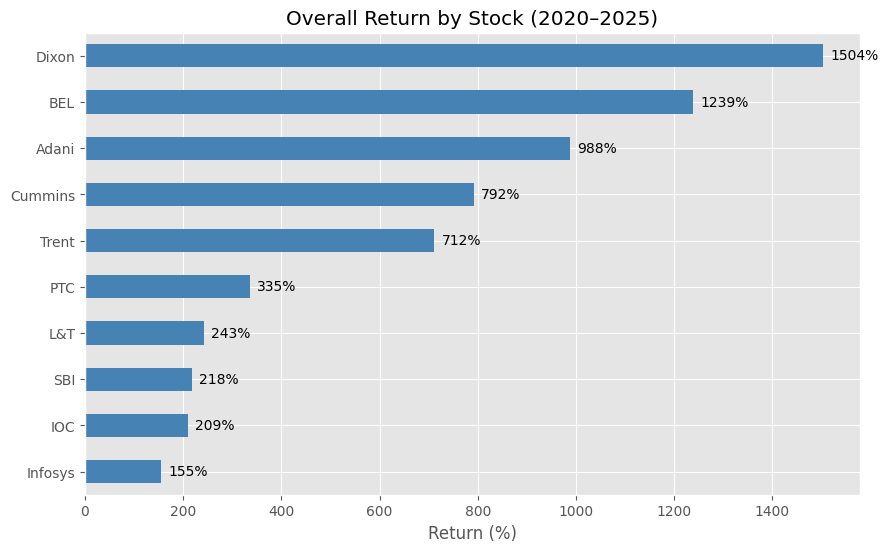

In [108]:
ax = returns.sort_values().plot(kind="barh", figsize=(10,6), color="steelblue")

for i, value in enumerate(returns.sort_values()):
    ax.text(value + 15, i, f"{value:.0f}%", va="center", fontsize=10)

plt.title("Overall Return by Stock (2020–2025)")
plt.xlabel("Return (%)")
plt.ylabel("")

plt.savefig("returns_bar.png", dpi=300, bbox_inches="tight")

plt.show()

Dixon generated the highest overall return during the analysis period, followed by BEL and Adani. Infosys, IOC and SBI delivered comparatively lower but more stable returns.

In [83]:
print(f"Analysis Period : 2020 - 2025")
print(f"Number of Stocks : {len(portfolio)}")
print(f"Annual Return : {annual_return*100:.2f}%")
print(f"Annual Risk : {annual_risk*100:.2f}%")
print(f"Sharpe Ratio : {sharpe:.2f}")
print(f"Best Performer : {returns.idxmax()}")
print(f"Worst Performer : {returns.idxmin()}")

Analysis Period : 2020 - 2025
Number of Stocks : 10
Annual Return : 37.04%
Annual Risk : 22.13%
Sharpe Ratio : 1.40
Best Performer : Dixon
Worst Performer : Infosys


Overall, the portfolio showed strong long-term growth despite market fluctuations during the COVID period and later corrections. Diversification across sectors helped balance risk, while growth-oriented stocks such as Dixon and BEL contributed significantly to overall returns.

In [87]:
print(f"Best Day : {portfolio_returns.max()*100:.2f}%")
print(f"Worst Day : {portfolio_returns.min()*100:.2f}%")

Best Day : 5.67%
Worst Day : -12.23%


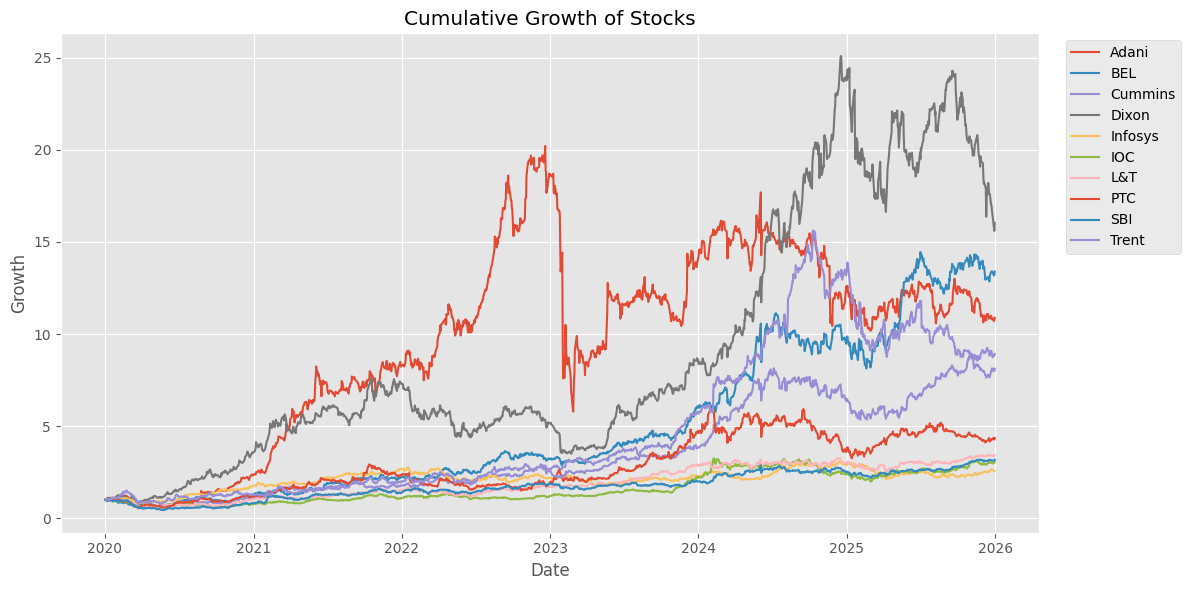

In [109]:
cumulative = (1 + daily_returns).cumprod()

plt.figure(figsize=(12,6))

for company in cumulative.columns:
    plt.plot(cumulative[company], label=company_names[company])

plt.title("Cumulative Growth of Stocks")
plt.xlabel("Date")
plt.ylabel("Growth")

plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout()

plt.savefig("cumulative_growth.png", dpi=300, bbox_inches="tight")

plt.show()

In [89]:
running_max = portfolio_growth.cummax()

drawdown = ((portfolio_growth - running_max) / running_max) * 100


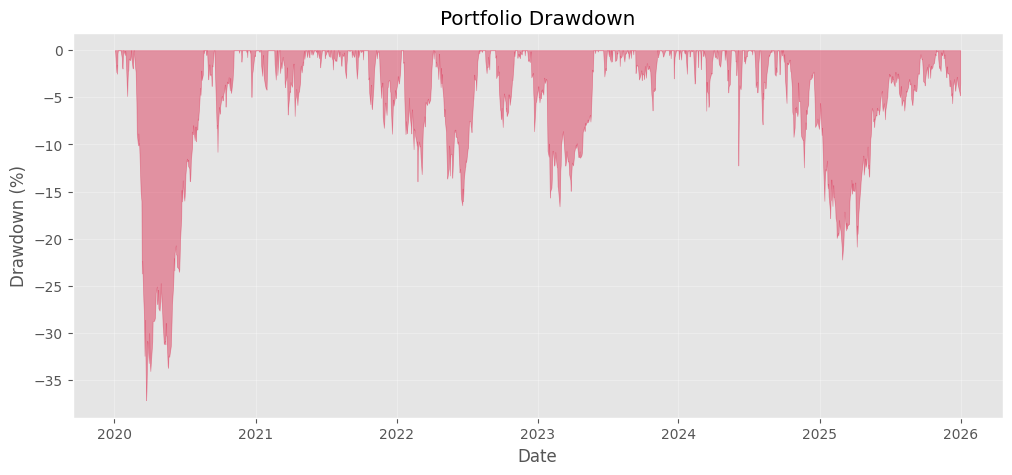

In [110]:
plt.figure(figsize=(12,5))

plt.fill_between(
    drawdown.index,
    drawdown,
    0,
    color="crimson",
    alpha=0.4
)

plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.grid(alpha=0.3)

plt.savefig("drawdown.png", dpi=300, bbox_inches="tight")

plt.show()



In [93]:
print(f"Maximum Drawdown: {drawdown.min():.2f}%")

Maximum Drawdown: -37.16%


Drawdown shows how much the portfolio fell from its previous highest value. It helps understand downside risk and the size of temporary losses during the investment period.

In [98]:
import os

os.makedirs("images", exist_ok=True)

In [113]:
!ls

correlation_heatmap.png  portfolio_allocation.png  sample_data
cumulative_growth.png	 portfolio_growth.png	   stock_prices.png
drawdown.png		 returns_bar.png
images			 risk_vs_return.png


• The portfolio delivered an annual return of about 37% over the analysis period.

• Dixon Technologies was the best-performing stock, while Infosys delivered the lowest overall return.

• Adani Enterprises showed the highest volatility, whereas Infosys and L&T were relatively stable.

• Most stocks had low to moderate positive correlation, indicating reasonable diversification.

• Despite market corrections, the portfolio generated strong long-term growth with a Sharpe Ratio above 1.